# Convolution Notebook


<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Import Libraries</h2>
</div>

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from copy import copy
import qickdawg as qd
import serial
import time
import pyvisa

from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from pathlib import Path

from datetime import datetime
import json

c:\Users\hlab_\anaconda3\envs\qickdawg_jeree\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Connect to Laser and Board</h2>
</div>

In [2]:
qd.start_client('10.225.208.77')
ser_laser = serial.Serial(
    port='COM3',
    baudrate=9600,
    stopbits=1,
    bytesize=8,
    parity='N',
    xonxoff=True)

ser_laser.write(b'*ON\r')
time.sleep(0.02)
ser_laser.write(b'EXT\r')
time.sleep(0.02)
#ser_laser.write(b'LAS\r')

<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Connect to DG535</h2>
</div>

In [3]:

# # SRS's standard channel numbering convention (also used on the DG645, etc.)
# CHANNELS = {
#     "T0": 0,
#     "A": 1,
#     "B": 2,
#     "AB": 3,
#     "C": 4,
#     "D": 5,
#     "CD": 6,
# }

# DELAY_CHANNELS = {
#     "T0": 1,
#     "A": 2,
#     "B": 3,
#     "C": 4,
#     "D": 5,
# }

# OUTPUT_MODES = {
#     "TTL": 0,
#     "NIM": 1,
#     "ECL": 2,
#     "VAR": 3,
# }


# class DG535:
#     def __init__(self, gpib_address: str, resource_manager: pyvisa.ResourceManager = None):
#         self.rm = resource_manager or pyvisa.ResourceManager()
#         self.inst = self.rm.open_resource(gpib_address)
#         self.inst.read_termination = "\r\n"
#         self.inst.write_termination = "\r\n"
#         self.inst.timeout = 5000  # ms

#     def clear(self):
#         """Reset the instrument's command buffer / status."""
#         self.inst.write("CL")

#     def set_trigger_external(self, level_v: float = 1.0, slope_positive: bool = True, fifty_ohm: bool = True):
#         """
#         Put the DG535 in EXTERNAL trigger mode (this is the fix for the
#         front panel showing 'INT' lit instead of 'EXT TRIG').
#         """
#         self.inst.write("TM 1")  # 0=Int, 1=Ext, 2=SS, 3=Burst
#         self.inst.write(f"TL {level_v}")
#         self.inst.write(f"TS {1 if slope_positive else 0}")
#         self.inst.write(f"TZ 0,{0 if fifty_ohm else 1}")

#     def set_delay(self, channel: str, ref_channel: str, delay_s: float):
#         """Set `channel`'s delay relative to `ref_channel`."""
#         self.inst.write(f"DT {DELAY_CHANNELS[channel]},{DELAY_CHANNELS[ref_channel]},{delay_s:.12f}")

#     def set_output_mode(self, channel: str, mode: str = "TTL"):
#         """channel: one of 'T0','A','B','AB','C','D','CD'. mode: TTL/NIM/ECL/VAR"""
#         self.inst.write(f"OM {CHANNELS[channel]},{OUTPUT_MODES[mode]}")

#     def set_output_amplitude(self, channel: str, volts: float):
#         """Only meaningful if that channel's mode is set to VAR."""
#         self.inst.write(f"OA {CHANNELS[channel]},{volts}")

#     def set_termination(self, channel: str, fifty_ohm: bool = True):
#         self.inst.write(f"TZ {CHANNELS[channel]},{0 if fifty_ohm else 1}")

#     def get_error_status(self) -> str:
#         return self.inst.query("ES")

#     def close(self):
#         self.inst.close()

#     def set_output_offset(self, channel: str, volts: float = 0.0):
#         """Explicitly zero (or set) the DC offset for this output."""
#         self.inst.write(f"OO {CHANNELS[channel]},{volts}")

#     def set_output_polarity(self, channel: str, normal: bool = True):
#         """
#         Set output polarity: normal (j=1) = idle low, pulses high.
#         Inverted (j=0) = idle high, pulses low -- this was the actual bug.
#         """
#         self.inst.write(f"OP {CHANNELS[channel]},{1 if normal else 0}")

In [4]:
# rm = pyvisa.ResourceManager()
# print("Available VISA resources:", rm.list_resources())

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">Close Connection</h3>
</div>

In [5]:
# qd.soc.reset_gens()   

In [6]:
# dg.close()

<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Connect to 20 MHz AWG</h2>
</div>

In [7]:
rm = pyvisa.ResourceManager()
print(rm.list_resources())

('USB0::0x05E6::0x2280::4593846::INSTR', 'ASRL3::INSTR', 'GPIB0::10::INSTR')


In [8]:

rm = pyvisa.ResourceManager()
awg = rm.open_resource('GPIB0::10::INSTR')

awg.write('*RST')                  # start from clean defaults
awg.write('FUNC PULS')             # pulse mode instead of sine
awg.write('PULS:WIDTH 1E-6')       # pulse width in seconds -- maps to your laser_on_tus
awg.write('PULS:PER 10E-6')        # period -- just a placeholder, real timing comes from trigger

awg.write('VOLT:HIGH 2.8')         # match laser's TRIG high level spec (2.8V)
awg.write('VOLT:LOW 0')
awg.write('OUTP:LOAD 50')          # laser's TRIG input is 50Ω terminated

awg.write('TRIG:SOUR EXT')         # wait for PMOD's external trigger
awg.write('TRIG:SLOP POS')         # match PMOD's trigger polarity (positive edge)
awg.write('BURS:STAT ON')          # burst mode: one pulse per trigger, not free-running
awg.write('BURS:NCYC 1')
awg.write('BURS:MODE TRIG')

awg.write('OUTP ON')               # enable the output

print(awg.query('SYST:ERR?'))      # check for command errors -- should print '+0,"No error"'

+0,"No error"



<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">Trigger Test</h3>
</div>

In [9]:
awg.write('TRIG:SOUR EXT')
awg.write('TRIG:SLOP POS')
print("Trigger source set to EXT:", awg.query('SYST:ERR?'))

Trigger source set to EXT: +0,"No error"



<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Gate Sweep Function</h2>
</div>
<a class="anchor" id="first-bullet"></a>

In [10]:
def run_and_save_gate_sweep(config, edge_label, laser_power, subfolder="Convolution_Msmnts"):
    """
    Runs a GateSweep measurement, then saves the plot (with params annotated
    on it), the raw data, and the full metadata -- all into one timestamped
    folder under `subfolder`.
    """
    program = qd.GateSweep(config)
    data = program.acquire(progress=True)

    # average over the reps axis, then drop the leftover size-1 axis
    data_mean = data.mean(axis=0).squeeze()

    # convert mean counts/rep -> counts per second, using the gate width
    gate_width_s = config.readout_integration_tns * 1e-9
    cps_mean = data_mean / gate_width_s

    delays_ns = (program.qick_sweeps[0].get_sweep_pts() * program.cycles2us(1) * 1000
                 - config.pre_offset_tns)

    # --- Create the experiment folder ---
    run_folder = create_experiment_folder(subfolder)

    # --- Build metadata ---
    metadata = {
        "edge": edge_label,
        "laser_power_percent": laser_power,
        "laser_on_tus": config.laser_on_tus,
        "gate_width_tns": config.readout_integration_tns,
        "pre_offset_tns": config.pre_offset_tns,
        "delay_start_tns": config.delay_start_tns,
        "delay_end_tns": config.delay_end_tns,
        "nsweep_points": config.nsweep_points,
        "reps": config.reps,
        "relax_delay_tns": config.relax_delay_tns,
        "high_threshold": config.high_threshold,
        "low_threshold": config.low_threshold,
        "timestamp": datetime.now().isoformat(),
    }
    save_metadata(run_folder, metadata)

    # --- Save raw data (both raw per-rep and averaged) ---
    np.savez(run_folder / "data.npz", delays_ns=delays_ns, counts_mean=data_mean, cps_mean=cps_mean, counts_raw=data)

    # --- Plot, with key params annotated directly on it ---
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(delays_ns, cps_mean, 'o-')
    ax.axvline(0, color='k', linestyle='--', linewidth=1, label='PMOD trigger sent (t=0)')
    ax.axvline(85, color='g', linestyle=':', linewidth=1, label='expected DG535 latency (~85 ns)')
    ax.axvline(config.laser_on_tus * 1000, color='r', linestyle='--', linewidth=1, label='laser off')
    ax.set_xlabel('delay relative to PMOD trigger (ns)')
    ax.set_ylabel('count rate (cps)')
    ax.set_title(f'GateSweep -- {edge_label} edge')
    ax.legend()

    param_text = (
        f"folder = {run_folder.name}\n"
        f"laser_on = {metadata['laser_on_tus']} us\n"
        f"gate width = {metadata['gate_width_tns']} ns\n"
        f"power = {metadata['laser_power_percent']}%\n"
        f"reps = {metadata['reps']}\n"
        f"sweep = {metadata['delay_start_tns']} to {metadata['delay_end_tns']} ns "
        f"(shifted by pre_offset={metadata['pre_offset_tns']} ns), {metadata['nsweep_points']} pts"
    )

    ax.text(0.02, 0.98, param_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    fig.savefig(run_folder / "plot.png", dpi=150)
    plt.show()

    print(f"Saved to: {run_folder}")

    return delays_ns, data_mean, run_folder

<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Assigning Default Configurations</h2>
</div>
<a class="anchor" id="first-bullet"></a>

These are standard settings used across most, if not all, qickdawg programs <br>
Commonly used attributes:
- adc_channel: 0 or 1 and should be DC coupled through a differential amplifier (adc_channel = 0 if following Readme)
- mw_channel: microwave exciation channel, can be 0 or 1 for RFSoC4x2 or 0 to 6 for ZCU111 & ZCU216
- mw_nqz: Nyquist zone for the microwave generator. 1 for f < fdss/2 and 2 for f> fdss/2 
- mw_gain: Effectively mw amplitude.  From 0 to 2e15-1, i.e. 32767
- laser_gate_pmod: PMOD channel used to gate the laser on/off
- relax_delay_t#: delay time at the end of a pulse sequence, typically 500ns is sufficient


In [11]:
default_config = qd.NVConfiguration()

default_config.adc_channel = 0
default_config.edge_counting = True

# Hysteresis thresholds prevent double-counting from noise: signal must rise above high_threshold to register a photon, then fall below low_threshold before it can register the next one
default_config.high_threshold = 8000
default_config.low_threshold = 500

default_config.mw_channel = 1
default_config.mw_nqz = 1
default_config.mw_gain = 5000

default_config.laser_gate_pmod = 0
default_config.adc_trigger_pmod = 1

default_config.relax_delay_tns = 2000  # between each rep, wait for everything to catch up

# --- GateSweep-specific ---
default_config.laser_on_tus = 8.0        # polarization pulse duration, literature-backed for V_B-

default_config.readout_integration_tns = 20    # START HERE, narrow gate. Shrink (10, 5, ...) once
                                          # you find where the hardware complains or stops changing.

default_config.delay_start_tns = -100    # sweep window straddling the laser turn-ON edge --
default_config.delay_end_tns = 300       # this is the edge the 50 ns AOM buffer normally protects

default_config.nsweep_points = 200
default_config.reps = 5000               # narrow gate -> few counts/rep -> average a lot

<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Laser Functions</h2>
</div>

In [12]:
def On():
    qd.laser_on(default_config)
    
def Off():
    SetPower(0)

def SetPower(power):
    command = f'PWR{power}\r'.encode()
    ser_laser.write(command)

<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Laser Triggering</h2>
</div>

In [13]:
# dg = DG535("GPIB0::15::INSTR", resource_manager=rm)  # confirmed via NI MAX scan
# dg.clear()

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">Configure Trigger</h3>
</div>

In [14]:


# # 1. Listen for the PMOD trigger from the RFSoC instead of firing internally
# dg.set_trigger_external(level_v=1.0, slope_positive=True, fifty_ohm=True)

# # 2. Configure the AB output -- wired to the laser's external trigger input
# pulse_start_s = 0.0        # fire A (pulse turn-on) right at the trigger (T0)
# pulse_width_s = 0.1 #1e-6       # 1 us pulse laser pulse length

# dg.set_delay("A", "T0", pulse_start_s)
# print("after A delay:", dg.get_error_status())
# dg.set_delay("B", "T0", pulse_start_s + pulse_width_s)
# print("after B delay:", dg.get_error_status())
# dg.set_output_mode("AB", "TTL")     # confirm TTL matches your laser's trigger spec
# print("after set output mode:", dg.get_error_status())
# dg.set_output_polarity("AB", normal=True)
# dg.set_output_offset("AB", -2.0)   # explicitly force baseline to 0V
# print("Error status:", dg.get_error_status())
# dg.set_output_amplitude("AB", 4.0)
# print("Error status:", dg.get_error_status())
# dg.set_termination("AB", fifty_ohm=True)
# print("after set termination:", dg.get_error_status())
# print("DG535 configured: external trigger -> AB pulse output.")
# print("Error status:", dg.get_error_status())

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">Slow Trigger</h3>
</div>

In [15]:
# try:
#     print("Sending slow trigger pulses... press stop (■) or Ctrl+C to stop.")
#     while True:
#         qd.laser_on(default_config)
#         time.sleep(0.05)
#         qd.laser_off(default_config)
#         time.sleep(0.5)   # long pause so each flash is clearly separated
# except KeyboardInterrupt:
#     qd.laser_off(default_config)
#     print("Stopped.")

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">Fast Trigger</h3>
</div>

In [16]:

# try:
#     print("Toggling laser... press the Jupyter stop button (■) or Ctrl+C to stop.")
#     while True:
#         qd.laser_on(default_config)
#         time.sleep(0.05)
#         qd.laser_off(default_config)
#         time.sleep(0.05)
# except KeyboardInterrupt:
#     qd.laser_off(default_config)
#     print("Stopped, laser off.")

<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Setup Saving</h2>
</div>

In [17]:
# Parent directory where all measurement data is saved
parent_save_dir = Path(r"C:\Users\hlab_\Box\Henriksen Lab Data\DefectMsmts\Data")

# Create it if it doesn't already exist (safe to run even if it does)
parent_save_dir.mkdir(parents=True, exist_ok=True)

print(f"Saving to: {parent_save_dir}")
print(f"Exists: {parent_save_dir.exists()}")

Saving to: C:\Users\hlab_\Box\Henriksen Lab Data\DefectMsmts\Data
Exists: True


<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">Save Functions</h3>
</div>

In [18]:
def create_experiment_folder(subfolder_name, parent_dir=parent_save_dir):
    """
    Creates a new timestamped, numbered experiment folder inside
    parent_dir/subfolder_name, and returns the Path to it.
    """
    subfolder_path = parent_dir / subfolder_name
    subfolder_path.mkdir(parents=True, exist_ok=True)

    # Count existing experiment folders to figure out the next experiment number
    existing_experiments = [p for p in subfolder_path.iterdir() if p.is_dir()]
    experiment_number = len(existing_experiments) + 1

    timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
    experiment_folder = subfolder_path / f"{timestamp}_{experiment_number:03d}"
    experiment_folder.mkdir(parents=True, exist_ok=False)

    return experiment_folder

def save_metadata(run_folder, params: dict, filename="metadata.json"):
    with open(run_folder / filename, "w") as f:
        json.dump(params, f, indent=4)

def run_and_save_gate_sweep(config, edge_label, laser_power):
    """
    Runs a GateSweep measurement, then saves the plot (with params annotated
    on it), the raw data, and the full metadata -- all into one timestamped
    folder under Polarization_Msmnts.
    """
    program = qd.GateSweep(config)
    data = program.acquire(progress=True)

    # average over the reps axis, then drop the leftover size-1 axis
    data_mean = data.mean(axis=0).squeeze()

     # convert mean counts/rep -> counts per second, using the gate width
    gate_width_s = config.readout_integration_tns * 1e-9
    cps_mean = data_mean / gate_width_s

    # raw hardware delay, in real time from rep start -- NOT shifted by
    # pre_offset, since pre_offset doesn't reliably track the laser's
    # actual firing time right now
    delays_ns = program.qick_sweeps[0].get_sweep_pts() * program.cycles2us(1) * 1000

    # --- Create the experiment folder ---
    run_folder = create_experiment_folder("Convolution_Msmnts")

    # --- Build metadata ---
    metadata = {
        "edge": edge_label,
        "laser_power_percent": laser_power,
        "laser_on_tus": config.laser_on_tus,
        "gate_width_tns": config.readout_integration_tns,
        "pre_offset_tns": config.pre_offset_tns,
        "delay_start_tns": config.delay_start_tns,
        "delay_end_tns": config.delay_end_tns,
        "nsweep_points": config.nsweep_points,
        "reps": config.reps,
        "relax_delay_tns": config.relax_delay_tns,
        "high_threshold": config.high_threshold,
        "low_threshold": config.low_threshold,
        "timestamp": datetime.now().isoformat(),
    }
    save_metadata(run_folder, metadata)

    # --- Save raw data (both raw per-rep and averaged) ---
    np.savez(run_folder / "data.npz", delays_ns=delays_ns, counts_mean=data_mean, counts_raw=data)

     # --- Plot, with key params annotated directly on it ---
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(delays_ns, cps_mean, 'o-')
    ax.set_xlabel('delay (raw hardware time from rep start, ns)')
    ax.set_ylabel('count rate (cps)')
    ax.set_title(f'GateSweep -- {edge_label} edge')
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
    ax.legend()

    param_text = (
        f"folder = {run_folder.name}\n"
        f"laser_on = {metadata['laser_on_tus']} us\n"
        f"gate width = {metadata['gate_width_tns']} ns\n"
        f"power = {metadata['laser_power_percent']}%\n"
        f"reps = {metadata['reps']}\n"
        f"sweep = {metadata['delay_start_tns']} to {metadata['delay_end_tns']} ns "
        f"(raw hardware time, pre_offset={metadata['pre_offset_tns']} ns not applied), "
        f"{metadata['nsweep_points']} pts"
    )

    ax.text(0.02, 0.98, param_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    fig.savefig(run_folder / "plot.png", dpi=150)
    plt.show()

    print(f"Saved to: {run_folder}")

    return delays_ns, data_mean, run_folder

def run_and_save_gate_sweep_apd(config, edge_label, laser_power):
    """
    Runs a GateSweep measurement using the APD (analog readout), then saves
    the plot (with params annotated on it), the raw data, and the full
    metadata -- all into one timestamped folder under Convolution_Msmnts.
    """
    program = qd.GateSweep(config)
    data = program.acquire(progress=True)

    data_mean = data.mean(axis=0).squeeze()
    signal_mean = data_mean

    delays_ns = program.qick_sweeps[0].get_sweep_pts() * program.cycles2us(1) * 1000

    # --- detect laser on/off edges directly from the data (threshold crossing) ---
    baseline = np.median(signal_mean[:len(signal_mean)//10])  # estimate from first 10% of points
    peak = signal_mean.max()
    threshold = baseline + 0.5 * (peak - baseline)  # 50% crossing point

    above_threshold = signal_mean > threshold
    rising_idx = np.argmax(above_threshold) if above_threshold.any() else None
    falling_idx = len(above_threshold) - np.argmax(above_threshold[::-1]) - 1 if above_threshold.any() else None

    laser_on_ns = delays_ns[rising_idx] if rising_idx is not None else None
    laser_off_ns = delays_ns[falling_idx] if falling_idx is not None else None

    # --- Create the experiment folder ---
    run_folder = create_experiment_folder("Convolution_Msmnts")

    metadata = {
        "edge": edge_label,
        "laser_power_percent": laser_power,
        "laser_on_tus": config.laser_on_tus,
        "gate_width_tns": config.readout_integration_tns,
        "pre_offset_tns": config.pre_offset_tns,
        "delay_start_tns": config.delay_start_tns,
        "delay_end_tns": config.delay_end_tns,
        "nsweep_points": config.nsweep_points,
        "reps": config.reps,
        "relax_delay_tns": config.relax_delay_tns,
        "detected_laser_on_ns": laser_on_ns,
        "detected_laser_off_ns": laser_off_ns,
        "timestamp": datetime.now().isoformat(),
    }
    save_metadata(run_folder, metadata)

    np.savez(run_folder / "data.npz", delays_ns=delays_ns, signal_mean=data_mean, signal_raw=data)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(delays_ns, signal_mean, 'o-', label='APD signal')

    if laser_on_ns is not None:
        ax.axvline(laser_on_ns, color='g', linestyle='--', linewidth=1.5,
                   label=f'laser on ({laser_on_ns:.0f} ns)')
    if laser_off_ns is not None:
        ax.axvline(laser_off_ns, color='r', linestyle='--', linewidth=1.5,
                   label=f'laser off ({laser_off_ns:.0f} ns)')

    ax.set_xlabel('delay (raw hardware time from rep start, ns)')
    ax.set_ylabel('APD signal (adc units)')
    ax.set_title(run_folder.name)
    

    param_text = (
        f"laser_on = {metadata['laser_on_tus']} us\n"
        f"gate width = {metadata['gate_width_tns']} ns\n"
        f"power = {metadata['laser_power_percent']}%\n"
        f"reps = {metadata['reps']}\n"
        f"sweep = {metadata['delay_start_tns']} to {metadata['delay_end_tns']} ns, "
        f"{metadata['nsweep_points']} pts"
    )

    ax.text(0.98, 0.98, param_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.legend(loc='upper right', bbox_to_anchor=(1.0, 0.65))

    plt.tight_layout()
    fig.savefig(run_folder / "plot.png", dpi=150)
    plt.show()

    print(f"Saved to: {run_folder}")

    return delays_ns, data_mean, run_folder


<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Run</h2>
</div>

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">Live Plot</h3>
</div>

In [19]:
# config = copy(default_config)

# config.readout_integration_treg = 2**14 # Maxium number of integrated points
# config.reps = 1 

# prog = qd.PLIntensity(config) 

# def get_cps():

#     d = prog.acquire(progress=False)

#     return d / qd.max_int_time_treg / qd.min_time_tns * 1e9


# qd.live_plot(get_cps)

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">Slow Trigger</h3>
</div>

In [20]:
SetPower(1)

In [21]:
# try:
#     print("Sending slow trigger pulses... press stop (■) or Ctrl+C to stop.")
#     while True:
#         qd.laser_on(default_config)
#         time.sleep(0.05)
#         qd.laser_off(default_config)
#         time.sleep(0.5)   # long pause so each flash is clearly separated
# except KeyboardInterrupt:
#     qd.laser_off(default_config)
#     print("Stopped.")

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">Gate Sweep-SPD</h3>
</div>

In [23]:
# synci_val = 0

# config = copy(default_config)
# laser_power = 1
# SetPower(laser_power)

# config.laser_on_tus = 0.6                
# config.readout_integration_tns = 100
# config.relax_delay_tns = 20000              

# config.pre_offset_tns = 20000
# config.delay_start_tns = 0
# config.delay_end_tns = 9498.7               
# config.nsweep_points = 1000

# config.reps = 1000                          
# config.synci_delay_tns = synci_val

# dg.set_trigger_external(level_v=1.0, slope_positive=True, fifty_ohm=True)
# dg.set_delay("A", "T0", 0.0)
# dg.set_delay("B", "T0", config.laser_on_tus * 1e-6)
# dg.set_output_mode("AB", "TTL")
# dg.set_output_polarity("AB", normal=False)
# dg.set_output_offset("AB", -2.0)
# dg.set_termination("AB", fifty_ohm=True)

# delays_ns, data_mean, run_folder = run_and_save_gate_sweep(
#     config, edge_label="turn_on_raw_time", laser_power=5
# )

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">Gate Sweep-APD</h3>
</div>

Reset PMOD If Stuck

In [26]:
#qd.soc.reset_gens()   

AWG config error check: +0,"No error"

pre_offset_treg = 307  pre_offset_tns = 999.3489583333334


100%|██████████| 180000/180000 [00:03<00:00, 45465.92it/s]


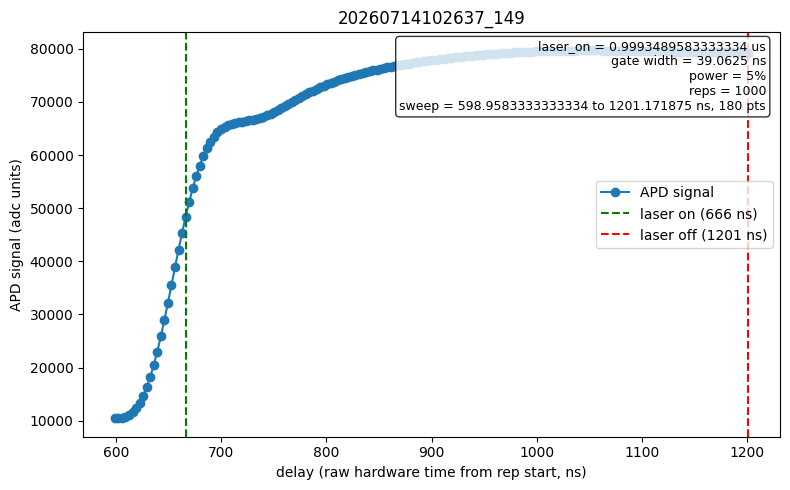

Saved to: C:\Users\hlab_\Box\Henriksen Lab Data\DefectMsmts\Data\Convolution_Msmnts\20260714102637_149


In [53]:
synci_val = 0

config = copy(default_config)
config.edge_counting = False        # <-- switches to analog readout for the APD

laser_power = 5
SetPower(laser_power)
config.pmod_pulse_tns = 100.0   # fixed, small width for the PMOD trigger pulse -- independent of laser_on_tus
config.laser_on_tus = 1.0
config.readout_integration_tns = 40 #Gate Width (acquisition time)
config.relax_delay_tns = 20000
config.reps = 1000

config.pre_offset_tns = 999.35
config.delay_start_tns = 600
config.delay_end_tns = 1200
config.nsweep_points = 180

# --- AWG setup, replacing the old DG535 block ---
awg.write('*RST')
awg.write('FUNC PULS')
awg.query('*OPC?')
awg.write(f'PULS:WIDTH {config.laser_on_tus * 1e-6}')   # matches laser_on_tus, same role as old dg.set_delay("B",...)
awg.write('PULS:PER 10E-6')

awg.write('VOLT:HIGH 2.8')
awg.write('VOLT:LOW 0')
awg.write('OUTP:LOAD 50')

awg.write('TRIG:SOUR EXT')
awg.write('TRIG:SLOP POS')
awg.write('BURS:STAT ON')
awg.write('BURS:NCYC 1')
awg.write('BURS:MODE TRIG')

awg.write('OUTP ON')
print("AWG config error check:", awg.query('SYST:ERR?'))

delays_ns, signal_mean, run_folder = run_and_save_gate_sweep_apd(
    config, edge_label="turn_on_awg", laser_power=laser_power
)

Loop

gate_width=40ns, reps=1250  AWG error check: +0,"No error"

pre_offset_treg = 307  pre_offset_tns = 999.3489583333334


100%|██████████| 212500/212500 [00:04<00:00, 45406.48it/s]


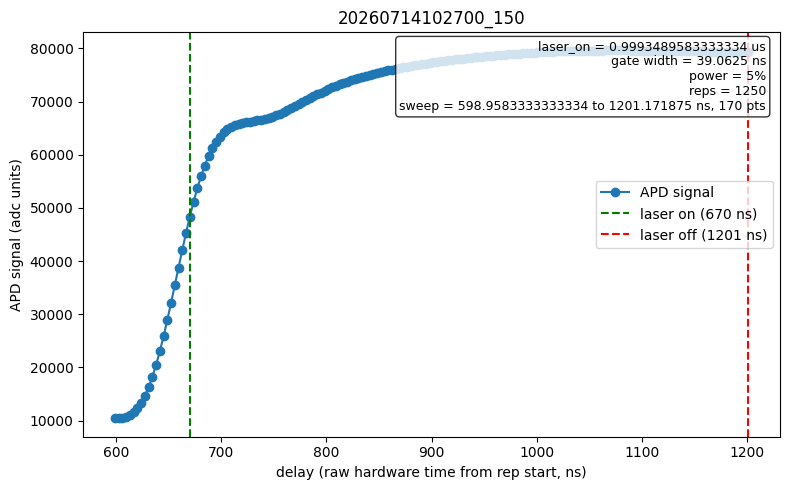

Saved to: C:\Users\hlab_\Box\Henriksen Lab Data\DefectMsmts\Data\Convolution_Msmnts\20260714102700_150
gate_width=45ns, reps=1111  AWG error check: +0,"No error"

pre_offset_treg = 307  pre_offset_tns = 999.3489583333334


100%|██████████| 188870/188870 [00:04<00:00, 45473.07it/s]


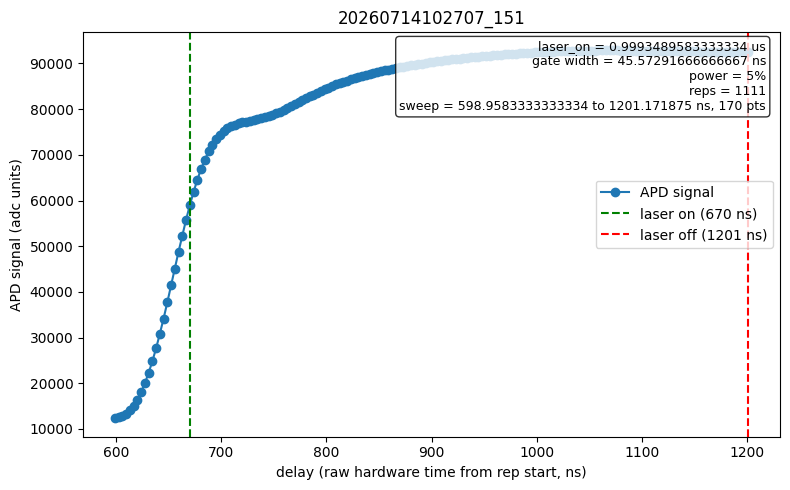

Saved to: C:\Users\hlab_\Box\Henriksen Lab Data\DefectMsmts\Data\Convolution_Msmnts\20260714102707_151
gate_width=50ns, reps=1000  AWG error check: +0,"No error"

pre_offset_treg = 307  pre_offset_tns = 999.3489583333334


100%|██████████| 170000/170000 [00:03<00:00, 45474.21it/s]


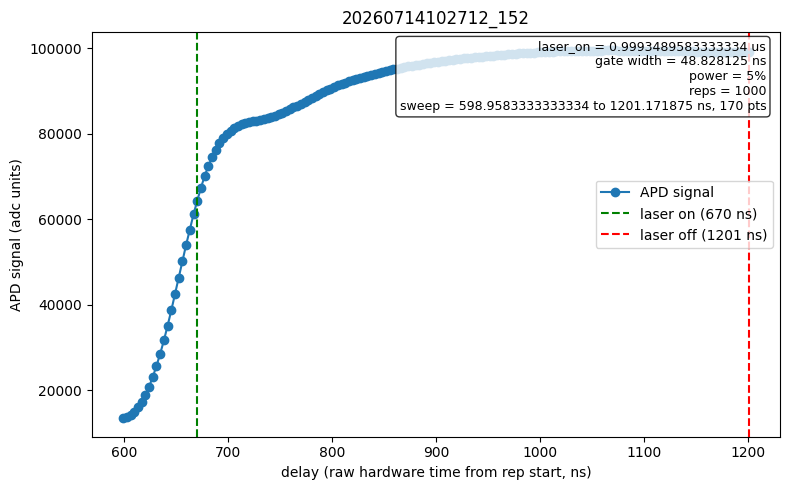

Saved to: C:\Users\hlab_\Box\Henriksen Lab Data\DefectMsmts\Data\Convolution_Msmnts\20260714102712_152
gate_width=55ns, reps=909  AWG error check: +0,"No error"

pre_offset_treg = 307  pre_offset_tns = 999.3489583333334


100%|██████████| 154530/154530 [00:03<00:00, 45459.39it/s]


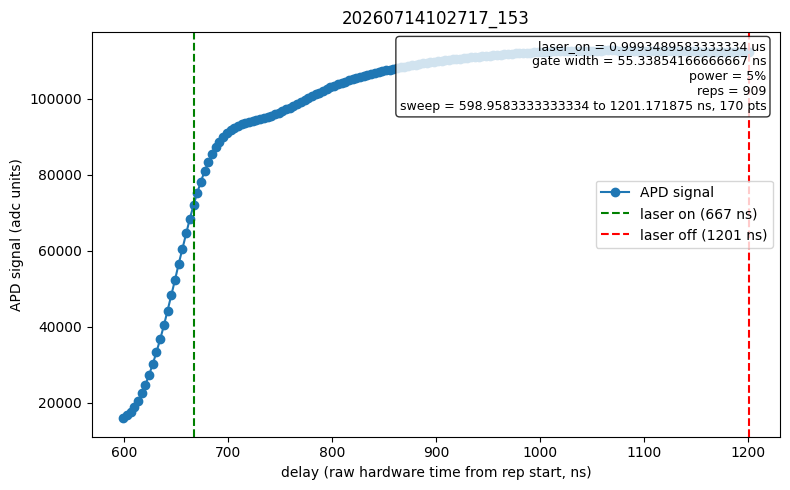

Saved to: C:\Users\hlab_\Box\Henriksen Lab Data\DefectMsmts\Data\Convolution_Msmnts\20260714102717_153
gate_width=60ns, reps=833  AWG error check: +0,"No error"

pre_offset_treg = 307  pre_offset_tns = 999.3489583333334


100%|██████████| 141610/141610 [00:03<00:00, 45476.57it/s]


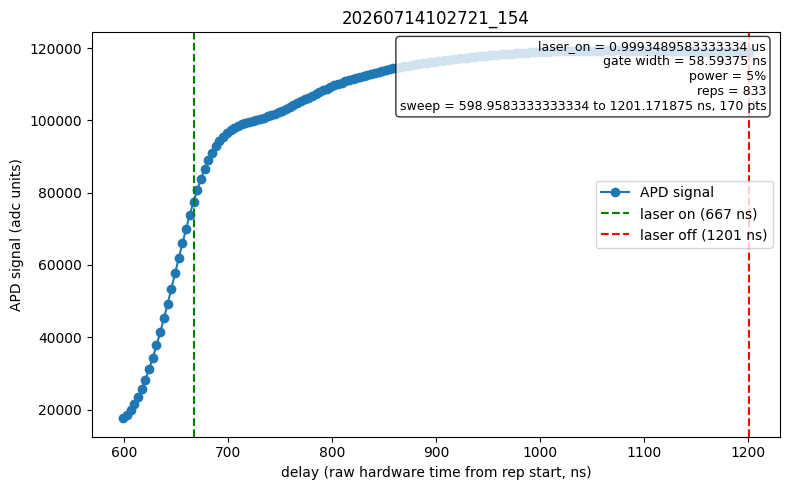

Saved to: C:\Users\hlab_\Box\Henriksen Lab Data\DefectMsmts\Data\Convolution_Msmnts\20260714102721_154
gate_width=65ns, reps=769  AWG error check: +0,"No error"

pre_offset_treg = 307  pre_offset_tns = 999.3489583333334


100%|██████████| 130730/130730 [00:02<00:00, 45342.44it/s]


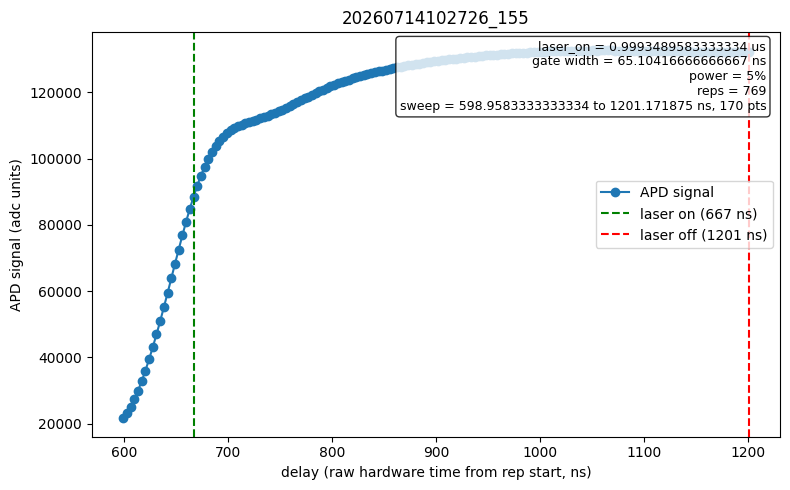

Saved to: C:\Users\hlab_\Box\Henriksen Lab Data\DefectMsmts\Data\Convolution_Msmnts\20260714102726_155
gate_width=70ns, reps=714  AWG error check: +0,"No error"

pre_offset_treg = 307  pre_offset_tns = 999.3489583333334


100%|██████████| 121380/121380 [00:02<00:00, 45300.55it/s]


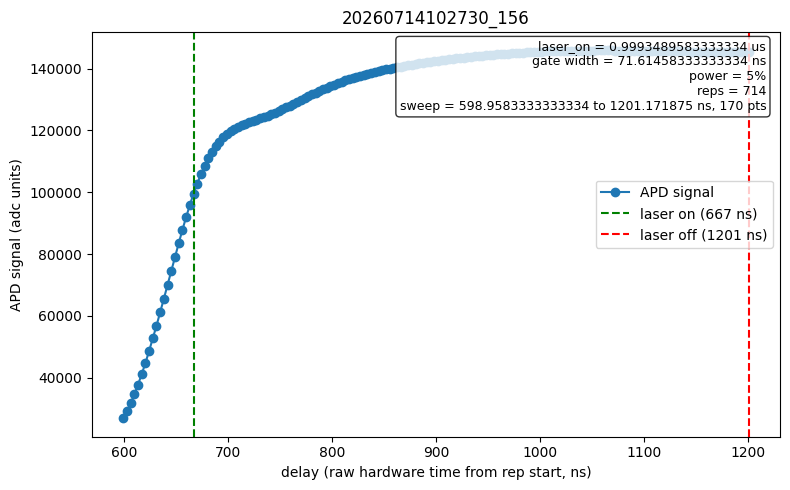

Saved to: C:\Users\hlab_\Box\Henriksen Lab Data\DefectMsmts\Data\Convolution_Msmnts\20260714102730_156
gate_width=75ns, reps=666  AWG error check: +0,"No error"

pre_offset_treg = 307  pre_offset_tns = 999.3489583333334


100%|██████████| 113220/113220 [00:02<00:00, 45407.64it/s]


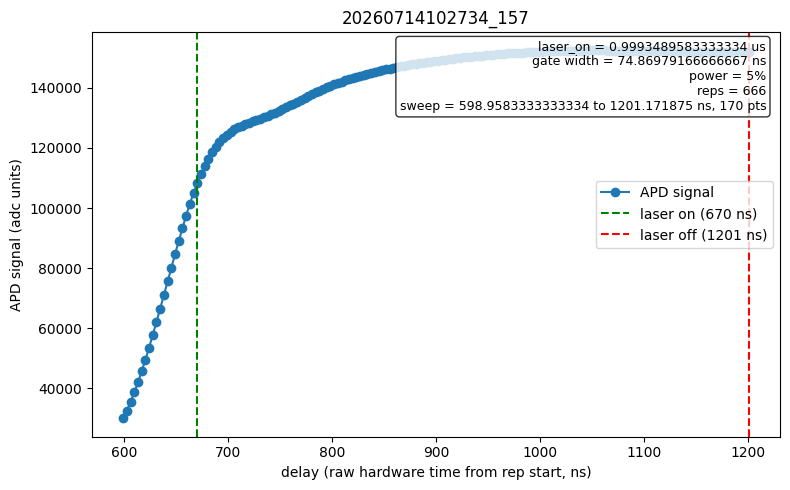

Saved to: C:\Users\hlab_\Box\Henriksen Lab Data\DefectMsmts\Data\Convolution_Msmnts\20260714102734_157
gate_width=80ns, reps=625  AWG error check: +0,"No error"

pre_offset_treg = 307  pre_offset_tns = 999.3489583333334


100%|██████████| 106250/106250 [00:02<00:00, 45275.50it/s]


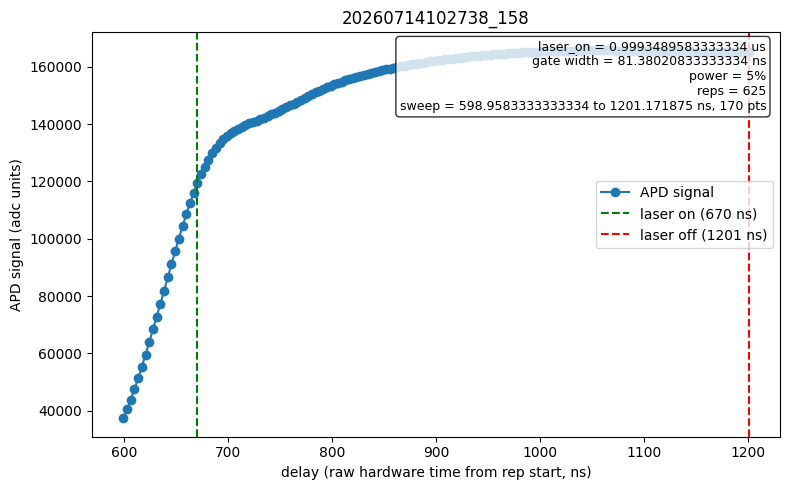

Saved to: C:\Users\hlab_\Box\Henriksen Lab Data\DefectMsmts\Data\Convolution_Msmnts\20260714102738_158
Done. Collected 9 runs.


In [54]:
gate_widths_ns = [40, 45, 50, 55, 60, 65, 70, 75, 80]
base_reps = 1000
base_width = 50   # reference

results = []

for gw in gate_widths_ns:
    synci_val = 0

    config = copy(default_config)
    config.edge_counting = False

    laser_power = 5
    SetPower(laser_power)
    config.pmod_pulse_tns = 100.0
    config.laser_on_tus = 1.0
    config.readout_integration_tns = gw
    config.relax_delay_tns = 20000
    config.reps = int(base_reps * base_width / gw)

    config.pre_offset_tns = 999.35
    config.delay_start_tns = 600
    config.delay_end_tns = 1200
    config.nsweep_points = 170   # safely under the ~185 tick-stall limit for this window

    # --- AWG setup ---
    awg.write('*RST')
    awg.write('FUNC PULS')
    awg.query('*OPC?')
    awg.write(f'PULS:WIDTH {config.laser_on_tus * 1e-6}')
    awg.write('PULS:PER 10E-6')

    awg.write('VOLT:HIGH 2.8')
    awg.write('VOLT:LOW 0')
    awg.write('OUTP:LOAD 50')

    awg.write('TRIG:SOUR EXT')
    awg.write('TRIG:SLOP POS')
    awg.write('BURS:STAT ON')
    awg.write('BURS:NCYC 1')
    awg.write('BURS:MODE TRIG')

    awg.write('OUTP ON')
    err = awg.query('SYST:ERR?')
    print(f"gate_width={gw}ns, reps={config.reps}  AWG error check: {err}")

    delays_ns, signal_mean, run_folder = run_and_save_gate_sweep_apd(
        config, edge_label=f"turn_on_awg_gw{gw}ns", laser_power=laser_power
    )

    results.append((gw, delays_ns, signal_mean, run_folder))

print("Done. Collected", len(results), "runs.")